In [65]:
import gymnasium as gym
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path

In [ ]:

def argwhere(matrix, value):
  l = list()
  x_max,y_max=matrix.shape
  for x in range(x_max):
    for y in range(y_max):

      if matrix[x,y] == value:
        l.append([x,y])

  return l

def creaMatriceDistanze( percorsoFile, direzione):
  df = pd.read_csv(percorsoFile, sep = ';', header = None)
  matrice_distanze = df.to_numpy()
  traguardo = argwhere(matrice_distanze,2)

  larghezza, altezza=matrice_distanze.shape

  for x in range(larghezza):
    for y in range(altezza):
      if matrice_distanze[x,y] != -1:
        matrice_distanze[x,y] = -2

  a = matrice_distanze






  index = traguardo.copy() #secondo me ha più senso calcolare la distanza dalla prima cella del traguardo disponibile rispetto ad una (list([[35,50]]))


  for i in index:
    a[i[0],i[1]] = 0





  match direzione:
    case "destra":
      slider=[0,1]
    case "sinistra":
      slider=[0,-1]
    case "basso":
      slider=[1,0]
    case "alto":
      slider=[-1,0]
    case _:
      slider=[0,0]


  for i in index:
    i[0]=i[0]+slider[0]
    i[1]=i[1]+slider[1]
    a[i[0],i[1]]=1
  print(f"linea iniziale {index}")

  while len(index) != 0:
      i = index.pop(0)
      #bisogna capire come non fare andare all'indietro del traguardo
      if (i[1]-1) >= 0 and a[i[0],i[1]-1] == -2 and traguardo.count([i[0],i[1]-1]) == 0:
          a[i[0],i[1]-1] = a[i[0],i[1]]+1
          index.append([i[0],i[1]-1])

      if (i[1]+1) < altezza and a[i[0],i[1]+1] == -2  and traguardo.count([i[0],i[1]+1]) == 0:
          a[i[0],i[1]+1] = a[i[0],i[1]]+1
          index.append([i[0],i[1]+1])

      if (i[0]-1) >= 0 and a[i[0]-1,i[1]] == -2  and traguardo.count([i[0]-1,i[1]]) == 0:
          a[i[0]-1,i[1]] = a[i[0],i[1]]+1
          index.append([i[0]-1,i[1]])

      if (i[0]+1) < larghezza and a[i[0]+1,i[1]] == -2  and traguardo.count([i[0]+1,i[1]]) == 0:
          a[i[0]+1,i[1]] = a[i[0],i[1]]+1
          index.append([i[0]+1,i[1]])

  # 2. Convertiamo in DataFrame
  df = pd.DataFrame(a)

  # 3. Salviamo in CSV
  Path("../data/track_distance/").mkdir(parents=True, exist_ok=True) # crea la cartella se non esiste, evita errore
  nome_circuito = percorsoFile.split("/")[-1].split(".")[0]
  df.to_csv(f'../data/track_distance/{nome_circuito}_distance.csv', index=False, header=False)

  return a


def count_numpy_list(list_numpy, param):
  cont = 0
  for x in list_numpy:
    if x[0] == param[0] and x[1] == param [1]:
      cont = cont + 1

  return cont

In [67]:
class TrackEnv(gym.Env):



  def __init__(self):


    self.matrix = buildTrack()
    self.distance_matrix = creaMatriceDistanze("../data/tracks/track_imola.csv","destra")

    #self.width = width
    #self.height = height

    self.view_size = 7
    self.road_width = 5
    self.trajectory = list()


    coordinates = np.argwhere(self.matrix == 2)
    print(self.matrix)
    #coordinates = coordinates[:, [1, 0]]
    print(f"coordinate traguard:{coordinates}")




    self._target_location = np.array(coordinates, dtype = np.int32)


    #da cambiare
    self._agent_location = np.array(coordinates[self.road_width // 2], dtype = np.int32)
    print(f"coordinate pilota:{self._agent_location}")
    #capire come mettere direzione dinamica in base alla pista
    #self._agent_direction = math.pi
    self._agent_velocity = 1



    #COME VOGLIAMO MODELLARE IL NOSTRO AGENTE? VOGLIAMO CHE LE SUE AZIONE SIANO
    # SU, GIU, DESTRA E SINISTRA OPPURE DEL TIPO ACELLERA, FRENA, GIRA A DESTRA
    #E GIRA A SINISTRA

    #azione 0 è frena
    #azione 1 è accellera
    #azione 2 è gira a destra
    #azione 3 è gira a sinistra
    self.action_space = gym.spaces.Discrete(4)

    self._action_to_direction = {
            0: np.array([0, 1]),   # Move right (column + 1)
            1: np.array([-1, 0]),  # Move up (row - 1)
            2: np.array([0, -1]),  # Move left (column - 1)
            3: np.array([1, 0]),   # Move down (row + 1)
        }

    # SE VOLESSIMO USARE IL SECONDO TIPO DI AZIONI DOBBIAMO ANCHE DIRE ALL'AGENTE
    # IN CHE DIREZIONE STA ANDANDO, E QUINDI AGGIUNGERE UN VALORE ALLO STATO
    # POTREMMO FARE CHE LA DIREZIONE è SEMPLICEMENTE UN NUMERO FLOAT CHE INDICA
    # L'ANGOLO TRA UN IMMAGINARIA LINEA VERTICALE CHE PASSA PER IL PILOTA E LA
    # DIREZIONE EFFETTIVA DEL PILOTA
    # ESEMPIO SPAZIO OSSERVAZIONI FATTO DA CHAT

    self.observation_space = gym.spaces.Dict({  #i dict servono per spazi eterogenei
            # 1. La sottomatrice locale (come prima)
            "agent_view": gym.spaces.Box( #i box servono per spazi omogenei
                low=-2,
                high=2,
                shape=(self.view_size, self.view_size),
                dtype=np.int8
            ),

            # 2. La direzione (angolo in radianti o gradi)
            # Definiamo un array di shape=(1,) contenente un float
            # Esempio: da 0 a 2*PI (circa 6.28)
            #"direction": gym.spaces.Box(
            #    low=0,
            #    high=2 * math.pi,
            #    shape=(1,),
            #    dtype=np.float32
            #),

            #aggiungere velocità
            "velocity": gym.spaces.Box(
                low=0,
                high=self.matrix.shape[0],
                shape=(1,),
                dtype=np.float32
            )
        })





  def _get_obs(self):
    view_padding = self.view_size // 2
    max_x,max_y = self.matrix.shape

    # HO CAMBIAMO IL LOW DELLO SPAZIO DELLE OSSERVAZIONI DA -1 A -2 PERCHè SERVE
    # UN MODO PER INDICARE UNA CELLA CHE NON ESISTE

    # creo la matrice che vede il pilota
    view_matrix = np.matrix(np.ones(shape=(self.view_size, self.view_size)))
    # inizializzo tutte le celle viste dal pilota come non esistenti
    for i in range(self.view_size):
      view_matrix[i]=view_matrix[i]*-2
    #indice della prima cella (top-left) della matrice della vista pilota nella matrice grande
    tl_x = self._agent_location[0] - view_padding
    tl_y = self._agent_location[1] - view_padding

    view_matrix_x = range(tl_x, tl_x+self.view_size,1)
    view_matrix_y = range(tl_y, tl_y+self.view_size,1)

    #tengo soltanto gli indici interni alla matrice grande
    clipped_view_matrix_x = np.clip(view_matrix_x,0, max_x - 1)
    clipped_view_matrix_y = np.clip(view_matrix_y,0, max_y - 1)
    #rimuovo i duplicati creati da np.clip
    clipped_view_matrix_x = list(set(clipped_view_matrix_x))
    clipped_view_matrix_y = list(set(clipped_view_matrix_y))

    #copio i valori dalla matrice grande in quella della visione del pilota
    for x in clipped_view_matrix_x:
      for y in  clipped_view_matrix_y:
        view_matrix[x-tl_x , y-tl_y]=self.matrix[y,x]

    view_matrix = view_matrix.T


    return { "agent_view": view_matrix ,
            #"direction": self._agent_direction,
             "velocity":self._agent_velocity}





  #come info restituiamo la posizione e direzione del pilota
  def _get_info(self):
    return { "agent_location":self._agent_location,
            #"agent_direction":self._agent_direction,
             "agent_velocity":self._agent_velocity}



  #con reset, rimettiamo il pilora nella posizione iniziale dal traguard
  # e ristabiliamo la sua direzione
  def reset(self, seed = None, options = None):

    super().reset(seed=seed)

   # self._agent_direction = math.pi

    self._agent_velocity = 1

    coordinates = np.argwhere(self.matrix == 2)

    #coordinates = coordinates[:, [1, 0]]
    #da cambiare
    self._agent_location = np.array(coordinates[self.road_width // 2], dtype = np.int32)


    observation = self._get_obs()
    info = self._get_info()
    return observation, info







  def step(self, action):

    size = self.matrix.shape[0]
    direction = self._action_to_direction[action]

        # Update agent position, ensuring it stays within grid bounds
        # np.clip prevents the agent from walking off the edge
    self._agent_location = np.clip(
            self._agent_location + direction, 0, size - 1
        )

    print(f"AAAAAAAAAAAAAAAAAAAAAAAA:{self._agent_location}")

    self.trajectory.append(self._agent_location)
    print(f"Traiettoria:{self.trajectory}")
        # Check if agent reached the target
    terminated=False
    for x in self._target_location:
      if np.array_equal(x, self._agent_location):
           terminated = True

        # We don't use truncation in this simple environment
        # (could add a step limit here if desired)
    truncated = False
    # traguardo si attiva quando tutti i checkpoint sono stati traversati
    # se il tragurdo è traversato prima gli diamo un reward negativo assurdo
    # da aggingere logica reward negativo fuori strada
    reward = self.distance_matrix[self._agent_location[0],self._agent_location[1]]
    print(f"reward : {reward}")
    #reward = -1 costante + bonus checkpoint
    #reward = -(distanza_massima - distanza) costante checkpoint 2 volte -> reward negativo
    # reward = -( numero_reward_traguardo - distnza) costante + logica checkpoint
    # reward =

    observation = self._get_obs()
    info = self._get_info()

    return observation, reward, terminated, truncated, info





    return 0

  def render(self):
    colori = [
        '#90EE90', # -1: Erba (Verde)
        '#FFFFFF', #  0: Cordoli (Arancione)
        '#404040', #  1: Strada (Grigio)
        '#FF8C00'  #  2: Traguardo (Bianco)
    ]
    cmap_circuito = ListedColormap(colori)
    dim = self.matrix.shape[0]


    # Funziona perfettamente anche con liste di liste
    x, y = zip(*self.trajectory)

    # Se ti servono come liste (e non come tuple)
    x_linea = list(y)
    y_linea = list(x)


    plt.imshow(self.matrix,
               cmap=cmap_circuito,
               origin='lower',
               extent=[0, dim, 0, dim],
               vmin=-1,
               vmax=2)


# 3. Disegno della Linea (Traiettoria)
    plt.plot(x_linea, y_linea,
         color='red',       # Colore della linea
         linewidth=2,       # Spessore
         linestyle='-',     # Stile linea (continua)
         label='Traiettoria')

# Decorazioni
    plt.title("Circuito e Traiettoria")


    plt.show()


def buildTrack(fileName = "../data/tracks/track_imola.csv"):
  df = pd.read_csv(fileName, header = None
                   ,sep=';'
                   )
  matrice_circuito = df.to_numpy()
  print(f"Dimensioni matrice:{matrice_circuito.shape}")
  #print(matrice_circuito)
  return matrice_circuito







Dimensioni matrice:(60, 60)
linea iniziale [[48, 36], [49, 36], [50, 36], [51, 36], [52, 36]]
[[-1 -1 -1 ... -1 -1 -1]
 [-1 -1 -1 ... -1 -1 -1]
 [-1 -1 -1 ... -1 -1 -1]
 ...
 [-1 -1 -1 ... -1 -1 -1]
 [-1 -1 -1 ... -1 -1 -1]
 [-1 -1 -1 ... -1 -1 -1]]
coordinate traguard:[[48 35]
 [49 35]
 [50 35]
 [51 35]
 [52 35]]
coordinate pilota:[50 35]
AAAAAAAAAAAAAAAAAAAAAAAA:[49 35]
Traiettoria:[array([49, 35])]
reward : 0


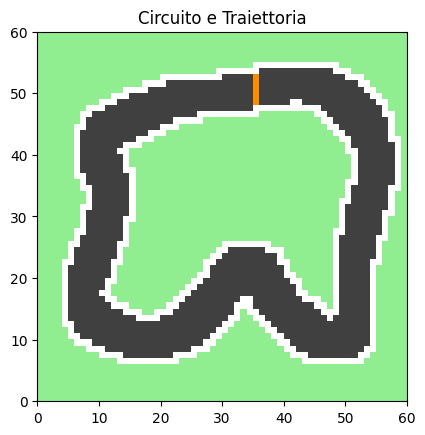

AAAAAAAAAAAAAAAAAAAAAAAA:[48 35]
Traiettoria:[array([49, 35]), array([48, 35])]
reward : 0


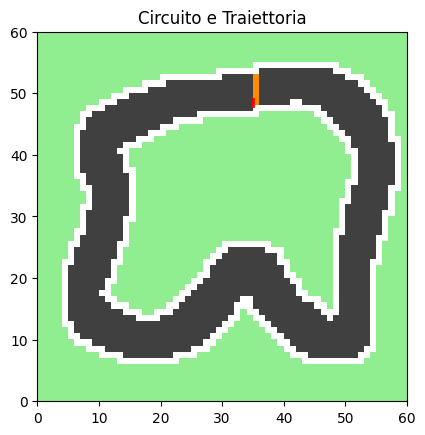

AAAAAAAAAAAAAAAAAAAAAAAA:[47 35]
Traiettoria:[array([49, 35]), array([48, 35]), array([47, 35])]
reward : 3


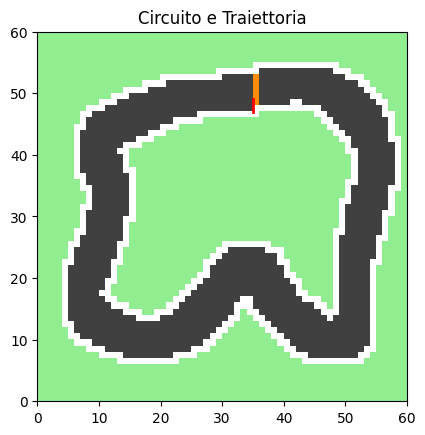

In [68]:
env = TrackEnv()
env.reset()
env.step(1)
env.render()
env.step(1)
env.render()
env.step(1)
env.render()